# Graph Neural Network (GNN)

## Part I) GIN implementation :

Implement a graph isomorphism network model (GIN), then test your implementation on the PROTEINS dataset.

The task is to predict if a protein is an enzyme or not. It's a graph level binary classification task.

To install torch_geometric : pip install torch_geometric

More info on : https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html

In [ ]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.7 MB/s eta 0:00:00


In [ ]:
#main import function and library
import torch_geometric as tg
import numpy as np
import torch
from torch_geometric.datasets import TUDataset
from torch.utils.data import random_split
from torch_geometric.loader import DataLoader
from torch.nn import Linear, Parameter
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import add_self_loops, degree
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv

from torch.nn import Linear, Sequential, BatchNorm1d, ReLU, Dropout
from torch_geometric.nn import GCNConv, GINConv
from torch_geometric.nn import global_mean_pool, global_add_pool
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx
# from mpl_toolkits.mplot3d import Axes3D

In [ ]:
dataset = tg.datasets.TUDataset(root='/tmp/PROTEINS', name='PROTEINS', use_node_attr=True)
dataset = dataset.shuffle()
train_dataset = dataset[:800]
val_dataset = dataset[800:956]
test_dataset = dataset[956:]


print('Number of training graphs: ',len(train_dataset))
print('Number of validation graphs: ',len(test_dataset))
print('Number of test graphs: ',len(test_dataset))

Number of training graphs:  800
Number of validation graphs:  157
Number of test graphs:  157


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [ ]:
print(dataset.num_node_features)


4


In [ ]:
class GCN(torch.nn.Module):
    """GCN"""
    def __init__(self, dim_h, dt):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(dt.num_node_features, dim_h)
        self.conv2 = GCNConv(dim_h, dim_h)
        self.conv3 = GCNConv(dim_h, dim_h)
        self.lin = Linear(dim_h, dt.num_classes)

    def forward(self, x, edge_index, batch):
        # Node embeddings
        h = self.conv1(x, edge_index)
        h = h.relu()
        h = self.conv2(h, edge_index)
        h = h.relu()
        h = self.conv3(h, edge_index)

        # Graph-level readout
        hG = global_mean_pool(h, batch)

        # Classifier
        h = F.dropout(hG, p=0.5, training=self.training)
        h = self.lin(h)

        return hG, F.log_softmax(h, dim=1)

class GIN(torch.nn.Module):
    """GIN"""
    def __init__(self, dim_h, dt):
        super(GIN, self).__init__()
        self.conv1 = GINConv(
            Sequential(Linear(dt.num_node_features, dim_h),
                       BatchNorm1d(dim_h), ReLU(),
                       Linear(dim_h, dim_h), ReLU()))
        self.conv2 = GINConv(
            Sequential(Linear(dim_h, dim_h), BatchNorm1d(dim_h), ReLU(),
                       Linear(dim_h, dim_h), ReLU()))
        self.conv3 = GINConv(
            Sequential(Linear(dim_h, dim_h), BatchNorm1d(dim_h), ReLU(),
                       Linear(dim_h, dim_h), ReLU()))
        self.lin1 = Linear(dim_h*3, dim_h*3)
        self.lin2 = Linear(dim_h*3, dt.num_classes)

    def forward(self, x, edge_index, batch):
        # Node embeddings
        h1 = self.conv1(x, edge_index)
        h2 = self.conv2(h1, edge_index)
        h3 = self.conv3(h2, edge_index)

        # Graph-level readout
        h1 = global_add_pool(h1, batch)
        h2 = global_add_pool(h2, batch)
        h3 = global_add_pool(h3, batch)

        # Concatenate graph embeddings
        h = torch.cat((h1, h2, h3), dim=1)

        # Classifier
        h = self.lin1(h)
        h = h.relu()
        h = F.dropout(h, p=0.5, training=self.training)
        h = self.lin2(h)

        return h, F.log_softmax(h, dim=1)

# gcn = GCN(dim_h=32)
gin = GIN(dim_h=32, dt=dataset)

In [ ]:
# Training function

def train(model, loader):
    print("Start Training...")
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(),
                                      lr=0.01,
                                      weight_decay=0.01)
    epochs = 100

    model.train()
    for epoch in range(epochs+1):
        total_loss = 0
        acc = 0
        val_loss = 0
        val_acc = 0

        # Train on batches
        for data in loader:
          optimizer.zero_grad()
          _, out = model(data.x, data.edge_index, data.batch)
          loss = criterion(out, data.y)
          total_loss += loss / len(loader)
          acc += accuracy(out.argmax(dim=1), data.y) / len(loader)
          loss.backward()
          optimizer.step()

          # Validation
          val_loss, val_acc = test(model, val_loader)

        # Print metrics every 10 epochs
        if(epoch % 10 == 0):
            print(f'Epoch {epoch:>3} | Train Loss: {total_loss:.2f} '
                  f'| Train Acc: {acc*100:>5.2f}% '
                  f'| Val Loss: {val_loss:.2f} '
                  f'| Val Acc: {val_acc*100:.2f}%')

    test_loss, test_acc = test(model, test_loader)
    print(f'Test Loss: {test_loss:.2f} | Test Acc: {test_acc*100:.2f}%')

    return model

@torch.no_grad()
def test(model, loader):
    criterion = torch.nn.CrossEntropyLoss()
    model.eval()
    loss = 0
    acc = 0

    for data in loader:
        _, out = model(data.x, data.edge_index, data.batch)
        loss += criterion(out, data.y) / len(loader)
        acc += accuracy(out.argmax(dim=1), data.y) / len(loader)

    return loss, acc

def accuracy(pred_y, y):
    """Calculate accuracy."""
    return ((pred_y == y).sum() / len(y)).item()


#####################################
gin = train(gin, train_loader)

Start Training...
Epoch   0 | Train Loss: 1.71 | Train Acc: 62.00% | Val Loss: 0.62 | Val Acc: 71.67%
Epoch  10 | Train Loss: 0.58 | Train Acc: 70.25% | Val Loss: 0.63 | Val Acc: 74.17%
Epoch  20 | Train Loss: 0.59 | Train Acc: 69.38% | Val Loss: 0.64 | Val Acc: 74.79%
Epoch  30 | Train Loss: 0.58 | Train Acc: 71.25% | Val Loss: 0.62 | Val Acc: 71.04%
Epoch  40 | Train Loss: 0.58 | Train Acc: 70.12% | Val Loss: 0.63 | Val Acc: 71.67%
Epoch  50 | Train Loss: 0.57 | Train Acc: 71.12% | Val Loss: 0.62 | Val Acc: 63.12%
Epoch  60 | Train Loss: 0.57 | Train Acc: 70.88% | Val Loss: 0.63 | Val Acc: 73.75%
Epoch  70 | Train Loss: 0.59 | Train Acc: 68.75% | Val Loss: 0.62 | Val Acc: 71.46%
Epoch  80 | Train Loss: 0.58 | Train Acc: 71.50% | Val Loss: 0.61 | Val Acc: 69.58%
Epoch  90 | Train Loss: 0.58 | Train Acc: 68.12% | Val Loss: 0.66 | Val Acc: 73.12%
Epoch 100 | Train Loss: 0.58 | Train Acc: 69.88% | Val Loss: 0.62 | Val Acc: 72.29%
Test Loss: 0.57 | Test Acc: 74.90%


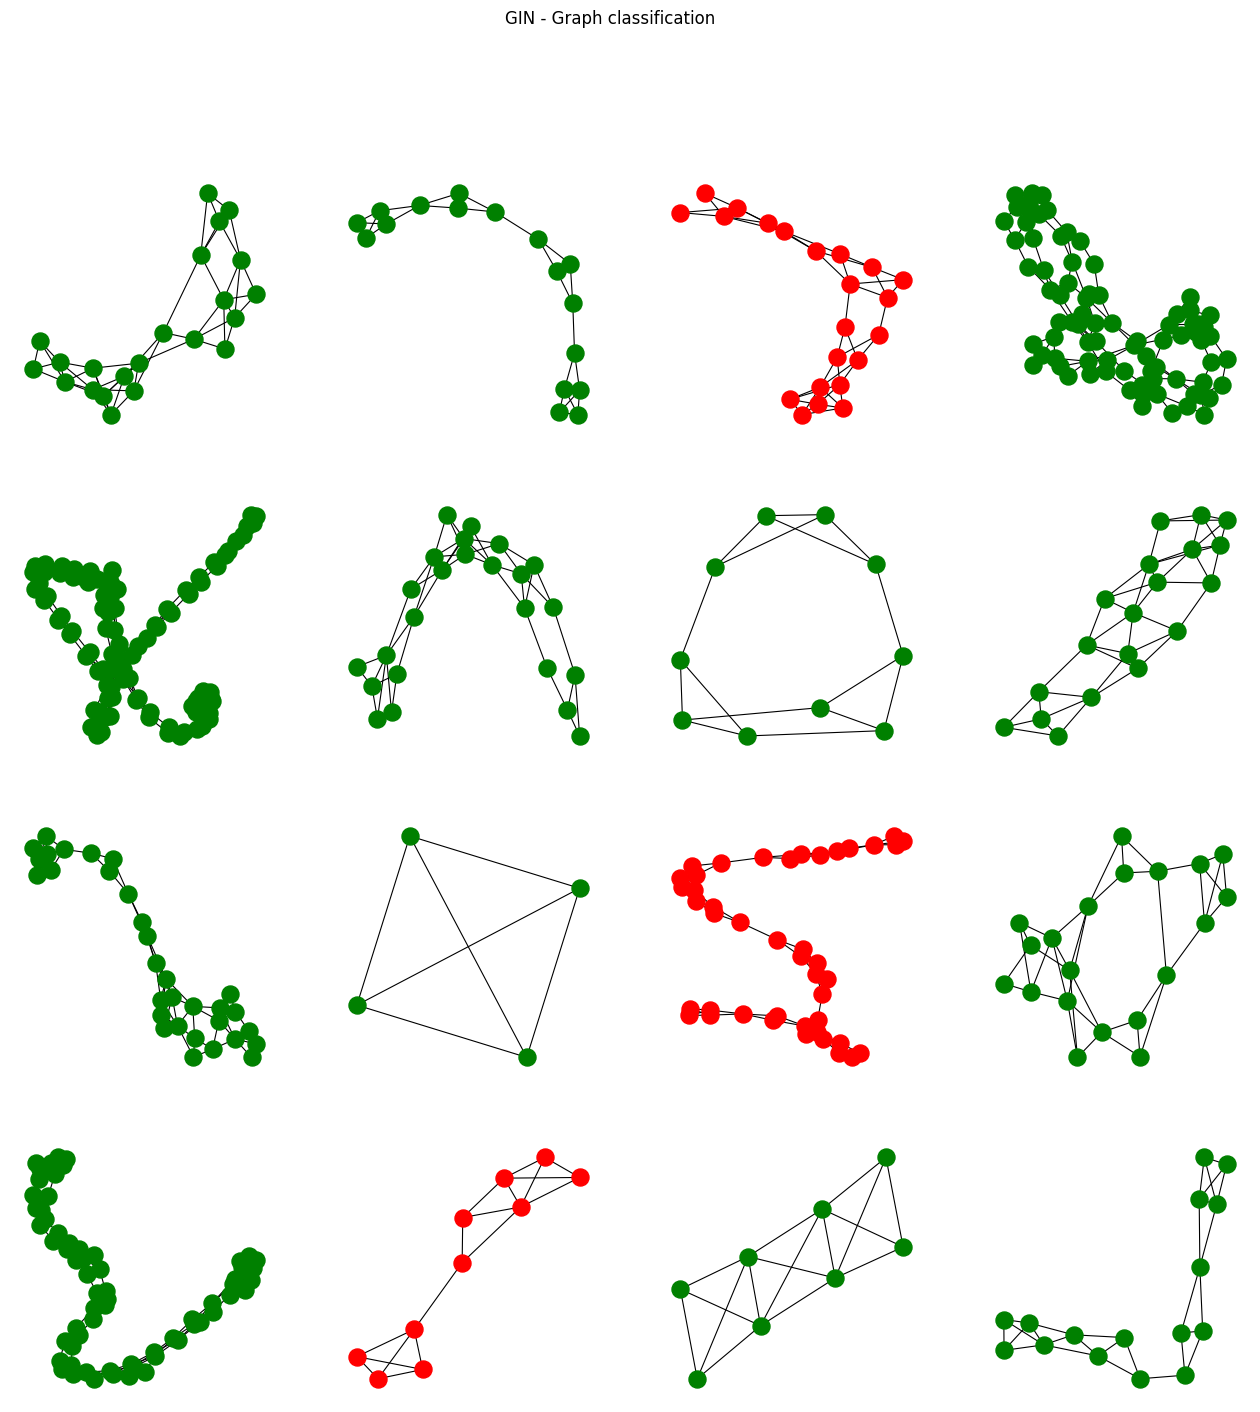

In [ ]:
fig, ax = plt.subplots(4, 4, figsize=(16,16))
fig.suptitle('GIN - Graph classification')

for i, data in enumerate(dataset[1113-16:]):
    # Calculate color (green if correct, red otherwise)
    _, out = gin(data.x, data.edge_index, data.batch)
    color = "green" if out.argmax(dim=1) == data.y else "red"

    # Plot graph
    ix = np.unravel_index(i, ax.shape)
    ax[ix].axis('off')
    G = to_networkx(dataset[i], to_undirected=True)
    nx.draw_networkx(G,
                    pos=nx.spring_layout(G, seed=0),
                    with_labels=False,
                    node_size=150,
                    node_color=color,
                    width=0.8,
                    ax=ax[ix]
                    )

In [ ]:
# To eval the model performances
def eval_model(model,loader):
    gin.eval()
    acc = 0

    for data in test_loader:
        # Get classifications
        _, out = gin(data.x, data.edge_index, data.batch)

        # Calculate accuracy scores
        acc += accuracy(out.argmax(dim=1), data.y) / len(test_loader)

    # Print results
    print(f'GIN accuracy:     {acc*100:.2f}%')
    return acc

# eval_model(gin,test_loader)

In [ ]:
torch.save(gin.state_dict(), 'gin_TP7.pt')

Explain what does the Aggregation and Update functions of GIN? Why it's called a message-passing architecture?

## Part II) Graph learning challenge

Now you have to implement and train a GNN on the ZFR database, you can certainly test your GIN from part I) but also any GNN you want (GCN, GAT...).

The goal is to predict three properties per graph, it's a graph regression task.

First, predict each property separately, then all three properties together.

This part of the practical work will be assessed on the basis of your experimental protocol and the results obtained.

Once your GNN is ready, download the test database and make predictions using your GNN.

You should submit your GNN predictions in a .csv file to Universitice. Your predictions should be in the same order as the test dataset. Your predictions should respect the following csv format:

- separator ";"
- column names : "prop1","prop2", "prop3", "allprop".
- for "allprop" your predictions should be a list of three values per graphs.
- csv file name :  yourName_GNNmodelName.csv

Any csv files that do not respect the above format will not be processed.

An accessible sheet will be filled with your name and your results (MAE and model name only) and a baseline (GCN model). You can submit any attempts of predictions, just modify your file on Universitice. The results will be processed every week before the practical session.

https://docs.google.com/spreadsheets/d/1fTZyV3DSa39vVlEYxN747YIGSR7ONoYEQc4Z3CHW3uM/edit?gid=0#gid=0

For the final rending of this work, you must submit to Universitice: this notebook, the code that gave you the best MAE entry (in .py or .ipynb file), but also a doc with all your reasoning, methodology and different experiments you had done and why.

For example: the list of hyperparameters and a short description of the model used to obtain your best result, the hyperparameterisation protocol, the different sizes of architectures, the number of trials you performed, the learning protocol, the tested loss, the tested layers, the learning rate, the scheduler, the drop-out, etc...

The goal of this challenge is not just to code a GNN, but to understand how to train a deep neural network well on graph data.

The final grade for this work will focus mainly on your results, your originality and the protocol you used. Good luck!

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv, global_add_pool
from torch_geometric.loader import DataLoader
from torch.utils.data import random_split, Subset
import numpy as np
import pandas as pd
import os
from itertools import product
import warnings

In [ ]:
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
      torch.cuda.manual_seed(seed)
      torch.backends.cudnn.deterministic = True
      torch.backends.cudnn.benchmark = False

set_seed(42)

#==================== GIN MODEL====================
class GINModel(nn.Module):
    def __init__(self, input_dim, output_dim=1, hidden_dim=64, num_layers=3, dropout=0.3):
        super(GINModel, self).__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        # Initial projection
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # GIN layers with residual connections
        self.gin_layers = nn.ModuleList()
        self.batch_norms = nn.ModuleList()

        for i in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim * 2),
                nn.BatchNorm1d(hidden_dim * 2),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim * 2, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU()
            )
            self.gin_layers.append(GINConv(mlp, train_eps=True))
            self.batch_norms.append(nn.BatchNorm1d(hidden_dim))

        # Output layer
        self.output_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, output_dim)
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # Initial projection
        x = self.input_proj(x)

        # Apply GIN layers with residual connections
        for i in range(self.num_layers):
            identity = x
            x = self.gin_layers[i](x, edge_index)
            x = self.batch_norms[i](x)
            x = F.relu(x)
            x = self.dropout(x)

            # Residual connection for deeper layers
            if i > 0:
                x = x + identity

        # Global pooling
        x = global_add_pool(x, batch)

        # Output layer
        x = self.output_head(x)

        return x

#==================== GRID SEARCH ====================
def grid_search_hyperparameters(train_loader, val_loader, input_dim, task='prop1',
  num_epochs=50, patience=10):
  """
  Perform grid search over hyperparameters
  """
  # Define hyperparameter grid
  learning_rates = [0.01, 0.001, 0.0001]
  batch_sizes = [32, 64]
  num_layers_list = [1, 2, 3]
  hidden_dims = [64, 128]
  best_params = None
  best_model = None
  best_val_loss = float('inf')
  results = []

  total_combinations = len(learning_rates) * len(batch_sizes) * len(num_layers_list) * len(hidden_dims)
  print(f"\nGrid Search: Testing {total_combinations} hyperparameter combinations")
  print("="*60)

  batch_size_loaders = {}
  for batch_size in batch_sizes:
      batch_size_loaders[batch_size] = DataLoader(
          train_loader.dataset,
          batch_size=batch_size,
          shuffle=True
      )

  comb_idx = 0
  for lr, batch_size, num_layers, hidden_dim in product(
      learning_rates, batch_sizes, num_layers_list, hidden_dims
  ):
      comb_idx += 1
      print(f"\n[{comb_idx}/{total_combinations}] Testing: lr={lr}, "
            f"batch={batch_size}, layers={num_layers}, hidden={hidden_dim}")

      # Create model
      if task == 'all':
          model = GINModel(
              input_dim=input_dim,
              output_dim=3,
              hidden_dim=hidden_dim,
              num_layers=num_layers
          ).to(device)
      else:
          model = GINModel(
              input_dim=input_dim,
              output_dim=1,
              hidden_dim=hidden_dim,
              num_layers=num_layers
          ).to(device)

      # Train with current hyperparameters
      val_loss = train_model_single_config(
          model,
          batch_size_loaders[batch_size],
          val_loader,
          task=task,
          learning_rate=lr,
          num_epochs=num_epochs,
          patience=patience,
          verbose=False
      )

      results.append({
          'lr': lr,
          'batch_size': batch_size,
          'num_layers': num_layers,
          'hidden_dim': hidden_dim,
          'val_loss': val_loss
      })

      if val_loss < best_val_loss:
          best_val_loss = val_loss
          best_params = {
              'lr': lr,
              'batch_size': batch_size,
              'num_layers': num_layers,
              'hidden_dim': hidden_dim
          }
          best_model = model
          print(f"  → New best! Val Loss: {val_loss:.6f}")

  print(f"\n{'='*60}")
  print(f"BEST HYPERPARAMETERS for {task}:")
  for key, value in best_params.items():
      print(f"  {key}: {value}")
  print(f"  Validation Loss: {best_val_loss:.6f}")
  print(f"{'='*60}")

  return best_model, best_params, results

#==================== TRAINING SINGLE CONFIG ====================
def train_model_single_config(model, train_loader, val_loader, task='prop1',
  learning_rate=0.001, num_epochs=50, patience=10,
  verbose=True):
  """
  Train a model with specific hyperparameters
  """
  criterion = nn.MSELoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
  scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
  optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6
  )

  best_val_loss = float('inf')
  patience_counter = 0

  for epoch in range(1, num_epochs + 1):
      # Training
      model.train()
      train_loss = 0
      train_total = 0

      for data in train_loader:
          data = data.to(device)

          if data.y is None:
              continue

          optimizer.zero_grad()
          predictions = model(data)

          # Get target for specific property
          if task in ['prop1', 'prop2', 'prop3']:
              prop_idx = {'prop1': 0, 'prop2': 1, 'prop3': 2}[task]
              targets = data.y[:, prop_idx].view(-1, 1)
          else:  # 'all' task
              targets = data.y

          # Ensure predictions have correct shape
          if task == 'all':
              if predictions.shape[1] != 3:
                  predictions = predictions.view(-1, 3)
              if targets.shape[1] != 3:
                  targets = targets.view(-1, 3)

          loss = criterion(predictions, targets)
          loss.backward()
          torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
          optimizer.step()

          train_loss += loss.item() * data.num_graphs
          train_total += data.num_graphs

      avg_train_loss = train_loss / train_total if train_total > 0 else 0.0

      # Validation
      model.eval()
      val_loss = 0
      val_total = 0

      with torch.no_grad():
          for data in val_loader:
              data = data.to(device)

              if data.y is None:
                  continue

              predictions = model(data)

              if task in ['prop1', 'prop2', 'prop3']:
                  prop_idx = {'prop1': 0, 'prop2': 1, 'prop3': 2}[task]
                  targets = data.y[:, prop_idx].view(-1, 1)
              else:
                  targets = data.y

              if task == 'all':
                  if predictions.shape[1] != 3:
                      predictions = predictions.view(-1, 3)
                  if targets.shape[1] != 3:
                      targets = targets.view(-1, 3)

              loss = criterion(predictions, targets)
              val_loss += loss.item() * data.num_graphs
              val_total += data.num_graphs

      avg_val_loss = val_loss / val_total if val_total > 0 else 0.0
      scheduler.step(avg_val_loss)

      if verbose and (epoch % 10 == 0 or epoch == 1):
          print(f"  Epoch {epoch:3d}: Train Loss: {avg_train_loss:.6f}, "
                f"Val Loss: {avg_val_loss:.6f}")

      # Early stopping
      if avg_val_loss < best_val_loss:
          best_val_loss = avg_val_loss
          patience_counter = 0
      else:
          patience_counter += 1

      if patience_counter >= patience:
          if verbose:
              print(f"  Early stopping at epoch {epoch}")
          break

  return best_val_loss

#==================== TRAIN FINAL MODEL ====================
def train_final_model(model, train_loader, val_loader, task='prop1',
    learning_rate=0.001, num_epochs=100, patience=15):
    """
    Train final model with best hyperparameters
    """
    print(f"\nTraining final model for {task}...")
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=7, min_lr=1e-6
    )

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(1, num_epochs + 1):
        # Training
        model.train()
        train_loss = 0
        train_total = 0

        for data in train_loader:
            data = data.to(device)

            if data.y is None:
                continue

            optimizer.zero_grad()
            predictions = model(data)

            if task in ['prop1', 'prop2', 'prop3']:
                prop_idx = {'prop1': 0, 'prop2': 1, 'prop3': 2}[task]
                targets = data.y[:, prop_idx].view(-1, 1)
            else:
                targets = data.y

            if task == 'all':
                if predictions.shape[1] != 3:
                    predictions = predictions.view(-1, 3)
                if targets.shape[1] != 3:
                    targets = targets.view(-1, 3)

            loss = criterion(predictions, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item() * data.num_graphs
            train_total += data.num_graphs

        avg_train_loss = train_loss / train_total if train_total > 0 else 0.0

        # Validation
        model.eval()
        val_loss = 0
        val_total = 0

        with torch.no_grad():
            for data in val_loader:
                data = data.to(device)

                if data.y is None:
                    continue

                predictions = model(data)

                if task in ['prop1', 'prop2', 'prop3']:
                    prop_idx = {'prop1': 0, 'prop2': 1, 'prop3': 2}[task]
                    targets = data.y[:, prop_idx].view(-1, 1)
                else:
                    targets = data.y

                if task == 'all':
                    if predictions.shape[1] != 3:
                        predictions = predictions.view(-1, 3)
                    if targets.shape[1] != 3:
                        targets = targets.view(-1, 3)

                loss = criterion(predictions, targets)
                val_loss += loss.item() * data.num_graphs
                val_total += data.num_graphs

        avg_val_loss = val_loss / val_total if val_total > 0 else 0.0
        scheduler.step(avg_val_loss)

        if epoch % 10 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}: Train Loss: {avg_train_loss:.6f}, "
                  f"Val Loss: {avg_val_loss:.6f}, "
                  f"LR: {optimizer.param_groups[0]['lr']:.6f}")

        # Early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"  Early stopping at epoch {epoch}")
            break

    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    print(f"  Best validation loss for {task}: {best_val_loss:.6f}")
    return model

#==================== MAKE PREDICTIONS ====================
def make_predictions_all_models(models_dict, test_loader):
    predictions_dict = {}
    for task, model in models_dict.items():
        model.eval()
        task_predictions = []

        with torch.no_grad():
            for data in test_loader:
                data = data.to(device)
                pred = model(data)
                task_predictions.append(pred.cpu())

        if task_predictions:
            predictions_dict[task] = torch.cat(task_predictions, dim=0)
        else:
            predictions_dict[task] = torch.tensor([])

    return predictions_dict

#==================== SAVE PREDICTIONS ====================
def save_predictions_to_csv(predictions_dict, filename="yourName_GINmodel.csv"):
    if predictions_dict.get('all') is None or len(predictions_dict['all']) == 0:
      raise ValueError("No predictions found for 'all' task!")
    prop1_pred = predictions_dict['prop1'].numpy().flatten()
    prop2_pred = predictions_dict['prop2'].numpy().flatten()
    prop3_pred = predictions_dict['prop3'].numpy().flatten()
    all_pred = predictions_dict['all'].numpy()

    if all_pred.ndim == 1:
        all_pred = all_pred.reshape(-1, 3)

    df = pd.DataFrame({
        'prop1': prop1_pred,
        'prop2': prop2_pred,
        'prop3': prop3_pred,
        'allprop': list(all_pred)
    })

    df.to_csv(filename, sep=';', index=False)
    print(f"\nPredictions saved to {filename}")

    print("\nFirst 5 predictions:")
    print(df.head().to_string(index=False))

    return df

# def compute_normalization(dataset):
#     xs = []
#     ys = []
#     for data in dataset:
#         if data.x is not None:
#             xs.append(data.x)
#         if data.y is not None:
#             ys.append(data.y)
#     x = torch.cat(xs, dim=0)
#     y = torch.cat(ys, dim=0)
#     return x.mean(0), x.std(0) + 1e-8, y.mean(0), y.std(0) + 1e-8

# class NormalizeTransform:
#     def __init__(self, x_mean, x_std, y_mean, y_std):
#         self.x_mean = x_mean
#         self.x_std = x_std
#         self.y_mean = y_mean
#         self.y_std = y_std

#     def __call__(self, data):
#         if data.x is not None:
#             data.x = (data.x - self.x_mean) / self.x_std
#         if data.y is not None:
#             data.y = (data.y - self.y_mean) / self.y_std
#         return data

def compute_normalization(dataset):
    xs = []
    for data in dataset:
        if data.x is not None:
            xs.append(data.x)
    x = torch.cat(xs, dim=0)
    return x.mean(0), x.std(0) + 1e-8  # Only return x stats

class NormalizeTransform:
    def __init__(self, x_mean, x_std):
        self.x_mean = x_mean
        self.x_std = x_std

    def __call__(self, data):
        if data.x is not None:
            data.x = (data.x - self.x_mean) / self.x_std
        # Don't normalize y
        return data



In [ ]:
#==================== MAIN EXECUTION ====================
# Import dataset
try:
    from ZFRdataset import ZFR
except ImportError:
    print("Error: Could not import ZFR dataset.")

print("\nLoading datasets...")
dataset_train = ZFR('dataset/ZFR', dataset='train')
dataset_test = ZFR('dataset/ZFR', dataset='test')

# --- NORMALIZATION (fit on TRAIN ONLY) ---
# x_mean, x_std, y_mean, y_std = compute_normalization(dataset_train)

# norm_transform = NormalizeTransform(x_mean, x_std, y_mean, y_std)

# dataset_train.transform = norm_transform
# dataset_test.transform = norm_transform

# --- NORMALIZATION (fit on TRAIN ONLY) ---
x_mean, x_std = compute_normalization(dataset_train)  # Only get x stats

norm_transform = NormalizeTransform(x_mean, x_std)  # Only pass x stats

dataset_train.transform = norm_transform
dataset_test.transform = norm_transform

# Split subset into train/val
val_ratio = 0.2
val_size = int(len(dataset_train) * val_ratio)
train_size = len(dataset_train) - val_size

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(
    dataset_train,
    [train_size, val_size],
    generator=generator
)

print(f"\nData Split:")
print(f"  Training set: {len(train_dataset)} samples")
print(f"  Validation set: {len(val_dataset)} samples")
print(f"  Test set: {len(dataset_test)} samples")

# Determine input dimension
sample_data = dataset_train[0]
input_dim = sample_data.x.shape[1] if sample_data.x is not None else 1
print(f"\nInput dimension: {input_dim}")

# Create data loaders for grid search (use smaller batch for grid search)
train_loader_grid = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Dictionary to store best models and their hyperparameters
hp_task1 = {'lr': 0.001
            , 'batch_size': 64
            , 'num_layers': 3
            , 'hidden_dim': 128}
hp_task2 = {'lr': 0.01
            , 'batch_size': 32
            , 'num_layers': 2
            , 'hidden_dim': 64}
hp_task3 = {'lr': 0.001
            , 'batch_size': 32
            , 'num_layers': 1
            , 'hidden_dim': 128}
hp_taskall = {'lr': 0.001
            , 'batch_size': 32
            , 'num_layers': 3
            , 'hidden_dim': 128}
models_dict = {}
best_params_dict = {
    'prop1': hp_task1,
    'prop2': hp_task2,
    'prop3': hp_task3,
    'all': hp_taskall
}

# Tasks to train
# tasks = ['prop1', 'prop2', 'prop3', 'all']
tasks = ['prop3', 'all']

for task in tasks:
    # print(f"\n{'='*60}")
    # print(f"HYPERPARAMETER TUNING FOR: {task}")
    # print(f"{'='*60}")

    # # Perform grid search
    # best_model, best_params, search_results = grid_search_hyperparameters(
    #     train_loader_grid,
    #     val_loader,
    #     input_dim,
    #     task=task,
    #     num_epochs=30,  # Shorter epochs for grid search
    #     patience=5
    # )

    # # Save best parameters
    # best_params_dict[task] = best_params

    best_params = best_params_dict[task]

    # Train final model with best hyperparameters (using full training loader with optimal batch size)
    optimal_batch_size = best_params['batch_size']
    final_train_loader = DataLoader(
        train_dataset,
        batch_size=optimal_batch_size,
        shuffle=True
    )
    final_val_loader = DataLoader(
        val_dataset,
        batch_size=optimal_batch_size,
        shuffle=False
    )

    # Create new model with best architecture
    if task == 'all':
        final_model = GINModel(
            input_dim=input_dim,
            output_dim=3,
            hidden_dim=best_params['hidden_dim'],
            num_layers=best_params['num_layers']
        ).to(device)
    else:
        final_model = GINModel(
            input_dim=input_dim,
            output_dim=1,
            hidden_dim=best_params['hidden_dim'],
            num_layers=best_params['num_layers']
        ).to(device)

    # Train final model
    final_model = train_final_model(
        final_model,
        final_train_loader,
        final_val_loader,
        task=task,
        learning_rate=best_params['lr'],
        num_epochs=100,  # Longer training for final model
        patience=15
    )

    models_dict[task] = final_model

    # Save individual model
    torch.save(final_model.state_dict(), f'best_model_{task}.pth')
    print(f"  Saved best model for {task}")

# Create test loader with optimal batch size from 'all' task
optimal_test_batch = best_params_dict['all']['batch_size']
test_loader = DataLoader(dataset_test, batch_size=optimal_test_batch, shuffle=False)

# Make predictions
print(f"\n{'='*60}")
print("MAKING PREDICTIONS ON TEST SET")
print(f"{'='*60}")

predictions_dict = make_predictions_all_models(models_dict, test_loader)

# Save predictions
csv_filename = "yourName_GINmodel.csv"
df = save_predictions_to_csv(predictions_dict, csv_filename)

# Save all models and hyperparameters
torch.save({
    'models_dict': {k: v.state_dict() for k, v in models_dict.items()},
    'best_params_dict': best_params_dict,
    'input_dim': input_dim
}, 'all_trained_models.pth')

print(f"\n{'='*60}")
print("PROGRAM COMPLETE")
print(f"{'='*60}")
print(f"\nSummary of best hyperparameters:")
for task, params in best_params_dict.items():
    print(f"  {task}: lr={params['lr']}, batch={params['batch_size']}, "
          f"layers={params['num_layers']}, hidden={params['hidden_dim']}")
print(f"\n  Predictions saved to: {csv_filename}")
print(f"  Models saved to: all_trained_models.pth")

# return models_dict, best_params_dict, df



Loading datasets...

Data Split:
  Training set: 38784 samples
  Validation set: 9695 samples
  Test set: 9660 samples

Input dimension: 13

Training final model for prop3...
  Epoch   1: Train Loss: 0.011981, Val Loss: 0.000266, LR: 0.001000
  Epoch  10: Train Loss: 0.000190, Val Loss: 0.000175, LR: 0.001000
  Epoch  20: Train Loss: 0.000189, Val Loss: 0.000134, LR: 0.001000
  Epoch  30: Train Loss: 0.000174, Val Loss: 0.000121, LR: 0.000500
  Epoch  40: Train Loss: 0.000162, Val Loss: 0.000116, LR: 0.000250
  Epoch  50: Train Loss: 0.000155, Val Loss: 0.000107, LR: 0.000125
  Epoch  60: Train Loss: 0.000148, Val Loss: 0.000101, LR: 0.000063
  Epoch  70: Train Loss: 0.000144, Val Loss: 0.000098, LR: 0.000031
  Epoch  80: Train Loss: 0.000142, Val Loss: 0.000096, LR: 0.000016
  Early stopping at epoch 84
  Best validation loss for prop3: 0.000095
  Saved best model for prop3

Training final model for all...
  Epoch   1: Train Loss: 597.438259, Val Loss: 15.992511, LR: 0.001000
  Epoch

KeyError: 'prop1'


BEST HYPERPARAMETERS for prop1:
  lr: 0.001
  batch_size: 32
  num_layers: 3
  hidden_dim: 128
  Validation Loss: 0.358979


BEST HYPERPARAMETERS for prop2:
  lr: 0.001
  batch_size: 32
  num_layers: 2
  hidden_dim: 128
  Validation Loss: 0.029705


BEST HYPERPARAMETERS for prop3:
  lr: 0.001
  batch_size: 64
  num_layers: 3
  hidden_dim: 128
  Validation Loss: 0.143799


BEST HYPERPARAMETERS for all:
  lr: 0.001
  batch_size: 32
  num_layers: 3
  hidden_dim: 128
  Validation Loss: 0.207054



## V2 Model Selection

In [ ]:
#==================== MAIN EXECUTION ====================
print("="*60)
print("GIN MULTI-TASK REGRESSION WITH HYPERPARAMETER TUNING")
print("Using 20% of training data for faster experimentation")
print("="*60)

# Import dataset
try:
    from ZFRdataset import ZFR
except ImportError:
    print("Error: Could not import ZFR dataset.")

print("\nLoading datasets...")
dataset_train = ZFR('dataset/ZFR', dataset='train')
dataset_test = ZFR('dataset/ZFR', dataset='test')

# --- NORMALIZATION ---
# x_mean, x_std, y_mean, y_std = compute_normalization(dataset_train)

# norm_transform = NormalizeTransform(x_mean, x_std, y_mean, y_std)

# dataset_train.transform = norm_transform
# dataset_test.transform = norm_transform

# --- NORMALIZATION ---
x_mean, x_std = compute_normalization(dataset_train)

norm_transform = NormalizeTransform(x_mean, x_std)

dataset_train.transform = norm_transform
dataset_test.transform = norm_transform

# Use 20%
total_size = len(dataset_train)
subset_size = int(total_size * 0.2)

indices = torch.randperm(total_size)[:subset_size]
train_subset = Subset(dataset_train, indices)

val_ratio = 0.2
val_size = int(subset_size * val_ratio)
train_size = subset_size - val_size

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(
    train_subset,
    [train_size, val_size],
    generator=generator
)

print(f"\nData Split (using 20% of full dataset):")
print(f"  Training set: {len(train_dataset)} samples")
print(f"  Validation set: {len(val_dataset)} samples")
print(f"  Test set: {len(dataset_test)} samples")

# Determine input dimension
sample_data = dataset_train[0]
input_dim = sample_data.x.shape[1] if sample_data.x is not None else 1
print(f"\nInput dimension: {input_dim}")

# Create data loaders for grid search (use smaller batch for grid search)
train_loader_grid = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Dictionary to store best models and their hyperparameters
models_dict = {}
best_params_dict = {}

# Tasks to train
# tasks = ['prop1', 'prop2', 'prop3', 'all']
tasks = ['prop3', 'all']

for task in tasks:
    print(f"\n{'='*60}")
    print(f"HYPERPARAMETER TUNING FOR: {task}")
    print(f"{'='*60}")

    # Perform grid search
    best_model, best_params, search_results = grid_search_hyperparameters(
        train_loader_grid,
        val_loader,
        input_dim,
        task=task,
        num_epochs=30,  # Shorter epochs for grid search
        patience=5
    )

    # Save best parameters
    best_params_dict[task] = best_params

    # Train final model
    optimal_batch_size = best_params['batch_size']
    final_train_loader = DataLoader(
        train_dataset,
        batch_size=optimal_batch_size,
        shuffle=True
    )
    final_val_loader = DataLoader(
        val_dataset,
        batch_size=optimal_batch_size,
        shuffle=False
    )

    # Create new model with best architecture
    if task == 'all':
        final_model = GINModel(
            input_dim=input_dim,
            output_dim=3,
            hidden_dim=best_params['hidden_dim'],
            num_layers=best_params['num_layers']
        ).to(device)
    else:
        final_model = GINModel(
            input_dim=input_dim,
            output_dim=1,
            hidden_dim=best_params['hidden_dim'],
            num_layers=best_params['num_layers']
        ).to(device)

    # # Train final model
    # final_model = train_final_model(
    #     final_model,
    #     final_train_loader,
    #     final_val_loader,
    #     task=task,
    #     learning_rate=best_params['lr'],
    #     num_epochs=100,  # Longer training for final model
    #     patience=15
    # )

    # models_dict[task] = final_model

    # # Save individual model
    # torch.save(final_model.state_dict(), f'best_model_{task}.pth')
    # print(f"  Saved best model for {task}")

# Create test loader with optimal batch size from 'all' task
optimal_test_batch = best_params_dict['all']['batch_size']
test_loader = DataLoader(dataset_test, batch_size=optimal_test_batch, shuffle=False)

# Make predictions
print(f"\n{'='*60}")
print("MAKING PREDICTIONS ON TEST SET")
print(f"{'='*60}")

predictions_dict = make_predictions_all_models(models_dict, test_loader)

# Save predictions
csv_filename = "yourName_GINmodel.csv"
df = save_predictions_to_csv(predictions_dict, csv_filename)

# Save all models and hyperparameters
torch.save({
    'models_dict': {k: v.state_dict() for k, v in models_dict.items()},
    'best_params_dict': best_params_dict,
    'input_dim': input_dim
}, 'all_trained_models.pth')

print(f"\n{'='*60}")
print("PROGRAM COMPLETE")
print(f"{'='*60}")
print(f"\nSummary of best hyperparameters:")
for task, params in best_params_dict.items():
    print(f"  {task}: lr={params['lr']}, batch={params['batch_size']}, "
          f"layers={params['num_layers']}, hidden={params['hidden_dim']}")
print(f"\n  Predictions saved to: {csv_filename}")
print(f"  Models saved to: all_trained_models.pth")

# return models_dict, best_params_dict, df


GIN MULTI-TASK REGRESSION WITH HYPERPARAMETER TUNING
Using 20% of training data for faster experimentation

Loading datasets...

Data Split (using 20% of full dataset):
  Training set: 7756 samples
  Validation set: 1939 samples
  Test set: 9660 samples

Input dimension: 13

HYPERPARAMETER TUNING FOR: prop3

Grid Search: Testing 36 hyperparameter combinations

[1/36] Testing: lr=0.01, batch=32, layers=1, hidden=64
  → New best! Val Loss: 0.000179

[2/36] Testing: lr=0.01, batch=32, layers=1, hidden=128

[3/36] Testing: lr=0.01, batch=32, layers=2, hidden=64
  → New best! Val Loss: 0.000171

[4/36] Testing: lr=0.01, batch=32, layers=2, hidden=128

[5/36] Testing: lr=0.01, batch=32, layers=3, hidden=64

[6/36] Testing: lr=0.01, batch=32, layers=3, hidden=128

[7/36] Testing: lr=0.01, batch=64, layers=1, hidden=64

[8/36] Testing: lr=0.01, batch=64, layers=1, hidden=128
  → New best! Val Loss: 0.000163

[9/36] Testing: lr=0.01, batch=64, layers=2, hidden=64

[10/36] Testing: lr=0.01, batc

ValueError: No predictions found for 'all' task!

## V1

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv, global_add_pool
from torch_geometric.loader import DataLoader
from torch.utils.data import random_split
import numpy as np
import pandas as pd
import os

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

# ==================== GIN MODEL FOR SINGLE OUTPUT ====================
class GINSingleTask(nn.Module):
    def __init__(self, input_dim, output_dim=1, hidden_dim=64, num_layers=3, dropout=0.3):
        super(GINSingleTask, self).__init__()

        # Initial projection
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # GIN layers
        self.gin_layers = nn.ModuleList()
        for _ in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU()
            )
            self.gin_layers.append(GINConv(mlp, train_eps=True))

        # Output layer
        self.output_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, output_dim)
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # Initial projection
        x = self.input_proj(x)

        # Apply GIN layers
        for layer in self.gin_layers:
            x = layer(x, edge_index)
            x = F.relu(x)
            x = self.dropout(x)

        # Global pooling
        x = global_add_pool(x, batch)

        # Output layer
        x = self.output_head(x)

        return x


# ==================== GIN MODEL FOR MULTI-OUTPUT ====================
class GINMultiTask(nn.Module):
    def __init__(self, input_dim, output_dim=3, hidden_dim=64, num_layers=3, dropout=0.3):
        super(GINMultiTask, self).__init__()

        # Initial projection
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # GIN layers
        self.gin_layers = nn.ModuleList()
        for _ in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU()
            )
            self.gin_layers.append(GINConv(mlp, train_eps=True))

        # Output layer for 3 properties
        self.output_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim)
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # Initial projection
        x = self.input_proj(x)

        # Apply GIN layers
        for layer in self.gin_layers:
            x = layer(x, edge_index)
            x = F.relu(x)
            x = self.dropout(x)

        # Global pooling
        x = global_add_pool(x, batch)

        # Output layer
        x = self.output_head(x)

        return x


# ==================== TRAINING FUNCTION ====================
def train_model(model, train_loader, val_loader, task='prop1', num_epochs=50, patience=10):
    """
    Train a single model for a specific task
    """
    print(f"\n{'='*60}")
    print(f"Training model for task: {task}")
    print(f"{'='*60}")

    # Loss function (MSE for regression)
    criterion = nn.MSELoss()

    # Optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

    # Training tracking
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(1, num_epochs + 1):
        # Training
        model.train()
        train_loss = 0
        train_total = 0

        for data in train_loader:
            data = data.to(device)

            if data.y is None:
                continue

            optimizer.zero_grad()

            # Forward pass
            predictions = model(data)

            # Get target for specific property
            if task in ['prop1', 'prop2', 'prop3']:
                prop_idx = {'prop1': 0, 'prop2': 1, 'prop3': 2}[task]
                targets = data.y[:, prop_idx].view(-1, 1)
            else:  # 'all' task
                targets = data.y

            # Ensure predictions have correct shape
            if task == 'all':
                if predictions.shape[1] != 3:
                    predictions = predictions.view(-1, 3)
                if targets.shape[1] != 3:
                    targets = targets.view(-1, 3)

            # Calculate loss
            loss = criterion(predictions, targets)

            # Backward pass
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item() * data.num_graphs
            train_total += data.num_graphs

        avg_train_loss = train_loss / train_total if train_total > 0 else 0.0

        # Validation
        model.eval()
        val_loss = 0
        val_total = 0

        with torch.no_grad():
            for data in val_loader:
                data = data.to(device)

                if data.y is None:
                    continue

                predictions = model(data)

                # Get target for specific property
                if task in ['prop1', 'prop2', 'prop3']:
                    prop_idx = {'prop1': 0, 'prop2': 1, 'prop3': 2}[task]
                    targets = data.y[:, prop_idx].view(-1, 1)
                else:  # 'all' task
                    targets = data.y

                # Ensure predictions have correct shape
                if task == 'all':
                    if predictions.shape[1] != 3:
                        predictions = predictions.view(-1, 3)
                    if targets.shape[1] != 3:
                        targets = targets.view(-1, 3)

                loss = criterion(predictions, targets)
                val_loss += loss.item() * data.num_graphs
                val_total += data.num_graphs

        avg_val_loss = val_loss / val_total if val_total > 0 else 0.0

        # Update learning rate
        scheduler.step(avg_val_loss)

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d}/{num_epochs}: "
                  f"Train Loss: {avg_train_loss:.6f}, "
                  f"Val Loss: {avg_val_loss:.6f}, "
                  f"LR: {optimizer.param_groups[0]['lr']:.6f}")

        # Early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
            # Save the best model for this task
            torch.save(model.state_dict(), f'best_model_{task}.pth')
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping for task {task} at epoch {epoch}")
            break

    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"Loaded best model for {task} with validation loss: {best_val_loss:.6f}")

    return model


# ==================== MAKE PREDICTIONS WITH ALL MODELS ====================
def make_predictions_all_models(models_dict, test_loader):
    """
    Make predictions on test set with all four models
    """
    predictions_dict = {}

    for task, model in models_dict.items():
        model.eval()
        task_predictions = []

        with torch.no_grad():
            for data in test_loader:
                data = data.to(device)
                pred = model(data)
                task_predictions.append(pred.cpu())

        # Concatenate all predictions for this task
        if task_predictions:
            predictions_dict[task] = torch.cat(task_predictions, dim=0)
        else:
            predictions_dict[task] = torch.tensor([])

    return predictions_dict


# ==================== SAVE PREDICTIONS TO CSV ====================
def save_predictions_to_csv(predictions_dict, filename="yourName_GINmodel.csv"):
    """
    Save predictions to CSV with required format
    """
    # Check if we have predictions
    if predictions_dict.get('all') is None or len(predictions_dict['all']) == 0:
        raise ValueError("No predictions found for 'all' task!")

    # Convert tensors to numpy arrays
    prop1_pred = predictions_dict['prop1'].numpy().flatten()
    prop2_pred = predictions_dict['prop2'].numpy().flatten()
    prop3_pred = predictions_dict['prop3'].numpy().flatten()
    all_pred = predictions_dict['all'].numpy()

    # Ensure all_pred has shape (n_samples, 3)
    if all_pred.ndim == 1:
        all_pred = all_pred.reshape(-1, 3)

    # Create DataFrame with required format
    df = pd.DataFrame({
        'prop1': prop1_pred,
        'prop2': prop2_pred,
        'prop3': prop3_pred,
        'allprop': list(all_pred)  # Store as list of 3 values
    })

    # Save to CSV with semicolon separator
    df.to_csv(filename, sep=';', index=False)
    print(f"\nPredictions saved to {filename}")

    # Show sample of predictions
    print("\nFirst 5 predictions:")
    print(df.head().to_string(index=False))

    return df


# ==================== MAIN EXECUTION ====================
def main():
    print("="*60)
    print("GIN MULTI-TASK REGRESSION MODEL FOR ZFR DATASET")
    print("="*60)
    print("Training 4 separate models: prop1, prop2, prop3, all")
    print("="*60)

    # Import your dataset
    try:
        from ZFRdataset import ZFR
    except ImportError:
        print("Error: Could not import ZFR dataset. Please check the import path.")
        return

    print("\nLoading datasets...")
    dataset_train = ZFR('dataset/ZFR', dataset='train')
    dataset_test = ZFR('dataset/ZFR', dataset='test')

    # Data split (train/validation)
    val_ratio = 0.2
    total_size = len(dataset_train)
    val_size = int(total_size * val_ratio)
    train_size = total_size - val_size

    generator = torch.Generator().manual_seed(42)
    train_dataset, val_dataset = random_split(
        dataset_train,
        [train_size, val_size],
        generator=generator
    )

    print(f"\nData Split:")
    print(f"  Training set: {len(train_dataset)} samples")
    print(f"  Validation set: {len(val_dataset)} samples")
    print(f"  Test set: {len(dataset_test)} samples")

    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
    test_loader = DataLoader(dataset_test, batch_size=128, shuffle=False)

    # Determine input dimension
    sample_data = dataset_train[0]
    input_dim = sample_data.x.shape[1] if sample_data.x is not None else 1

    print(f"\nInput dimension: {input_dim}")

    # Dictionary to store all models
    models_dict = {}

    # Train model for prop1
    print("\n" + "="*60)
    print("1. Training model for prop1")
    print("="*60)
    model_prop1 = GINSingleTask(input_dim=input_dim, output_dim=1).to(device)
    models_dict['prop1'] = train_model(model_prop1, train_loader, val_loader, task='prop1')

    # Train model for prop2
    print("\n" + "="*60)
    print("2. Training model for prop2")
    print("="*60)
    model_prop2 = GINSingleTask(input_dim=input_dim, output_dim=1).to(device)
    models_dict['prop2'] = train_model(model_prop2, train_loader, val_loader, task='prop2')

    # Train model for prop3
    print("\n" + "="*60)
    print("3. Training model for prop3")
    print("="*60)
    model_prop3 = GINSingleTask(input_dim=input_dim, output_dim=1).to(device)
    models_dict['prop3'] = train_model(model_prop3, train_loader, val_loader, task='prop3')

    # Train model for all properties
    print("\n" + "="*60)
    print("4. Training model for all properties")
    print("="*60)
    model_all = GINMultiTask(input_dim=input_dim, output_dim=3).to(device)
    models_dict['all'] = train_model(model_all, train_loader, val_loader, task='all')

    # Make predictions with all models
    print("\n" + "="*60)
    print("MAKING PREDICTIONS ON TEST SET")
    print("="*60)
    print("Using all 4 trained models...")

    predictions_dict = make_predictions_all_models(models_dict, test_loader)

    # Save predictions to CSV
    csv_filename = "yourName_GINmodel.csv"
    df = save_predictions_to_csv(predictions_dict, csv_filename)

    # Save all models
    torch.save({
        'models_dict': {k: v.state_dict() for k, v in models_dict.items()},
        'input_dim': input_dim
    }, 'all_trained_models.pth')

    print("\n" + "="*60)
    print("PROGRAM COMPLETE")
    print("="*60)
    print(f"\nSummary:")
    print(f"  - 4 separate models trained:")
    print(f"     1. Model for prop1")
    print(f"     2. Model for prop2")
    print(f"     3. Model for prop3")
    print(f"     4. Model for all properties")
    print(f"  - Test predictions saved to: {csv_filename}")
    print(f"  - All models saved to: all_trained_models.pth")
    print(f"\nCSV file contains:")
    print(f"  - prop1: predictions from model trained only on prop1")
    print(f"  - prop2: predictions from model trained only on prop2")
    print(f"  - prop3: predictions from model trained only on prop3")
    print(f"  - allprop: predictions from model trained on all 3 properties")

    return models_dict, df


if __name__ == "__main__":
    # Run the main program
    models_dict, predictions_df = main()

GIN MULTI-TASK REGRESSION MODEL FOR ZFR DATASET
Training 4 separate models: prop1, prop2, prop3, all

Loading datasets...

Data Split:
  Training set: 38784 samples
  Validation set: 9695 samples
  Test set: 9660 samples

Input dimension: 13

1. Training model for prop1

Training model for task: prop1


KeyboardInterrupt: 